In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

DATA_PATH = r'C:\Users\Admin\hipython\ml\bermuda.project\data\encar_feature_processed_model_brand_labelencoded.csv'
df = pd.read_csv(DATA_PATH)

print(df.shape)
print(df.dtypes)
df.head()


(11617, 40)
매물ID                 int64
모델                  object
모델_원본               object
모델_LE                int64
모델_평균가_TE          float64
현재가격_만원              int64
주행거리_km              int64
배기량_cc               int64
좌석수                  int64
차량연령                 int64
사고강도점수               int64
주요옵션_선루프             int64
주요옵션_헤드램프 (LED)      int64
주요옵션_주차감지센서          int64
주요옵션_후방카메라           int64
주요옵션_자동에어컨           int64
주요옵션_스마트키            int64
주요옵션_내비게이션           int64
주요옵션_열선시트            int64
주요옵션_통풍시트            int64
주요옵션_가죽시트            int64
제조사_현대               int64
제조사_기아               int64
제조사_제네시스             int64
제조사_KG모빌리티(쌍용)       int64
제조사_쉐보레(GM대우)        int64
제조사_르노코리아(삼성)        int64
연료_LPG               int64
연료_가솔린               int64
연료_하이브리드             int64
연료_디젤                int64
연료_전기                int64
연료_수소                int64
색상_흰색                int64
색상_검정색               int64
색상_은색                int64
색상_기타           

,매물ID,모델,모델_원본,모델_LE,모델_평균가_TE,현재가격_만원,주행거리_km,배기량_cc,좌석수,차량연령,...,연료_디젤,연료_전기,연료_수소,색상_흰색,색상_검정색,색상_은색,색상_기타,변속기_오토계열,차급_SUV계열,차급_세단계열
0,37398208,렉스턴,렉스턴 스포츠 칸,35,2113.842105,1700,92801,2157,5,7,...,1,0,0,0,0,0,1,1,1,0
1,37424561,코란도,코란도 투리스모,92,658.918367,750,118621,2157,5,10,...,1,0,0,0,1,0,0,1,1,0
2,38020327,티볼리,티볼리 에어,105,1023.075269,650,120313,1597,5,10,...,1,0,0,1,0,0,0,1,1,0
3,38261140,코란도,코란도 투리스모,92,658.918367,650,82255,1998,5,12,...,1,0,0,1,0,0,0,1,1,0
4,38349931,렉스턴,G4 렉스턴,35,1783.857143,1670,93678,2157,5,9,...,1,0,0,0,1,0,0,1,1,0


In [2]:
# 불필요한 컬럼 제거 (ID, 텍스트 원본)
drop_cols = ['매물ID', '모델', '모델_원본', '모델_평균가_TE']
df = df.drop(columns=drop_cols)

# 피처 / 타겟 분리
TARGET = '현재가격_만원'
X = df.drop(columns=[TARGET])
y = df[TARGET]

# LGBM용 categorical feature 지정 (모델_LE)
cat_features_lgbm = ['모델_LE']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\n피처 목록:")
print(X.columns.tolist())


X shape: (11617, 35)
y shape: (11617,)

피처 목록:
['모델_LE', '주행거리_km', '배기량_cc', '좌석수', '차량연령', '사고강도점수', '주요옵션_선루프', '주요옵션_헤드램프 (LED)', '주요옵션_주차감지센서', '주요옵션_후방카메라', '주요옵션_자동에어컨', '주요옵션_스마트키', '주요옵션_내비게이션', '주요옵션_열선시트', '주요옵션_통풍시트', '주요옵션_가죽시트', '제조사_현대', '제조사_기아', '제조사_제네시스', '제조사_KG모빌리티(쌍용)', '제조사_쉐보레(GM대우)', '제조사_르노코리아(삼성)', '연료_LPG', '연료_가솔린', '연료_하이브리드', '연료_디젤', '연료_전기', '연료_수소', '색상_흰색', '색상_검정색', '색상_은색', '색상_기타', '변속기_오토계열', '차급_SUV계열', '차급_세단계열']


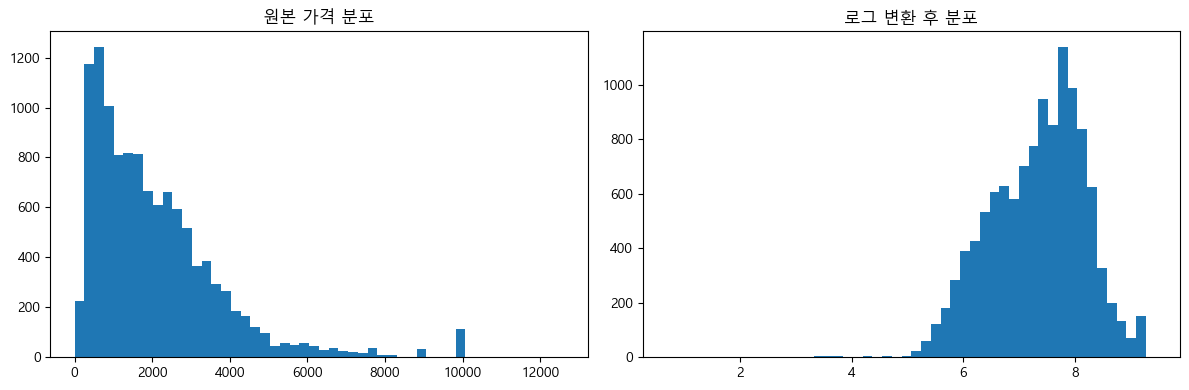

skewness (원본)  : 1.8887
skewness (로그)  : -0.4628


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=50)
axes[0].set_title('원본 가격 분포')

axes[1].hist(np.log1p(y), bins=50)
axes[1].set_title('로그 변환 후 분포')

plt.tight_layout()
plt.show()

print(f"skewness (원본)  : {y.skew():.4f}")
print(f"skewness (로그)  : {np.log1p(y).skew():.4f}")


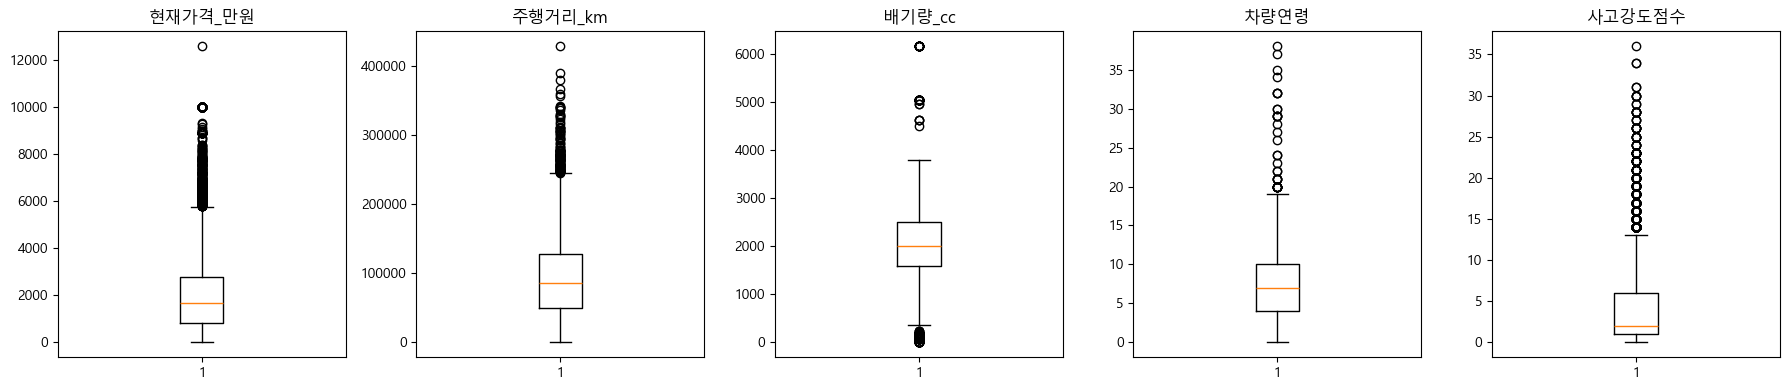

            현재가격_만원        주행거리_km        배기량_cc          차량연령        사고강도점수
count  11617.000000   11617.000000  11617.000000  11617.000000  11617.000000
mean    2082.699320   92198.832831   2100.557717      7.351898      3.879745
std     1698.301935   56053.984981    781.305282      3.992842      4.559099
min        1.000000       1.000000      0.000000      0.000000      0.000000
25%      829.000000   49230.000000   1598.000000      4.000000      1.000000
50%     1679.000000   85639.000000   1998.000000      7.000000      2.000000
75%     2800.000000  127884.000000   2497.000000     10.000000      6.000000
max    12590.000000  429407.000000   6162.000000     38.000000     36.000000


In [4]:
# 주요 수치형 컬럼 이상치 시각화
num_cols = ['현재가격_만원', '주행거리_km', '배기량_cc', '차량연령', '사고강도점수']

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

# 기초 통계로 범위 확인
print(df[num_cols].describe())


In [5]:
before = len(df)

# 가격 1만원 이하 제거 (명백한 오류)
df = df[df['현재가격_만원'] >= 100]

# IQR 기반 제거 (multiplier=3.0 : 극단값만 제거)
def remove_outliers_iqr(df, col, multiplier=3.0):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

for col in ['현재가격_만원', '주행거리_km', '차량연령', '사고강도점수']:
    df = remove_outliers_iqr(df, col)

# 배기량_cc=0 은 전기/수소차이므로 제거하지 않음
# 0이 아닌 경우만 IQR 적용
non_electric = df['배기량_cc'] > 0
df_electric = df[~non_electric]
df_non_electric = remove_outliers_iqr(df[non_electric], '배기량_cc')
df = pd.concat([df_electric, df_non_electric]).reset_index(drop=True)

after = len(df)
print(f"제거 전: {before}행 → 제거 후: {after}행 ({before - after}행 제거)")
print(df[['현재가격_만원', '주행거리_km', '배기량_cc', '차량연령', '사고강도점수']].describe())


제거 전: 11617행 → 제거 후: 11329행 (288행 제거)
            현재가격_만원        주행거리_km        배기량_cc          차량연령        사고강도점수
count  11329.000000   11329.000000  11329.000000  11329.000000  11329.000000
mean    1989.173360   92157.049431   2094.241151      7.340983      3.763616
std     1453.194862   55782.625965    766.629067      3.909009      4.250052
min      100.000000       1.000000      0.000000      0.000000      0.000000
25%      830.000000   49231.000000   1598.000000      4.000000      1.000000
50%     1650.000000   85732.000000   1998.000000      7.000000      2.000000
75%     2770.000000  127888.000000   2497.000000     10.000000      6.000000
max     8690.000000  360714.000000   5038.000000     28.000000     21.000000


In [6]:
# 피처 / 타겟 분리 (타겟 로그 변환)
TARGET = '현재가격_만원'
X = df.drop(columns=[TARGET])
y = np.log1p(df[TARGET])

# LGBM용 categorical feature 지정
cat_features_lgbm = ['모델_LE']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("피처 목록:", X.columns.tolist())


X shape: (11329, 35)
y shape: (11329,)
피처 목록: ['모델_LE', '주행거리_km', '배기량_cc', '좌석수', '차량연령', '사고강도점수', '주요옵션_선루프', '주요옵션_헤드램프 (LED)', '주요옵션_주차감지센서', '주요옵션_후방카메라', '주요옵션_자동에어컨', '주요옵션_스마트키', '주요옵션_내비게이션', '주요옵션_열선시트', '주요옵션_통풍시트', '주요옵션_가죽시트', '제조사_현대', '제조사_기아', '제조사_제네시스', '제조사_KG모빌리티(쌍용)', '제조사_쉐보레(GM대우)', '제조사_르노코리아(삼성)', '연료_LPG', '연료_가솔린', '연료_하이브리드', '연료_디젤', '연료_전기', '연료_수소', '색상_흰색', '색상_검정색', '색상_은색', '색상_기타', '변속기_오토계열', '차급_SUV계열', '차급_세단계열']


In [7]:
# 학습 / 테스트 분할 (8:2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (9063, 35)
X_test : (2266, 35)


In [8]:
# ── Random Forest ────────────────────────────────────────────
rf_model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Random Forest 학습 완료")

Random Forest 학습 완료


In [9]:
# ── LightGBM ─────────────────────────────────────────────────
lgbm_model = lgb.LGBMRegressor(n_estimators=300, random_state=42, n_jobs=-1)
lgbm_model.fit(
    X_train, y_train,
    categorical_feature=cat_features_lgbm
)
print("LightGBM 학습 완료")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000593 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 537
[LightGBM] [Info] Number of data points in the train set: 9063, number of used features: 35
[LightGBM] [Info] Start training from score 7.309478
LightGBM 학습 완료


In [10]:
# ── CatBoost ─────────────────────────────────────────────────
cat_features_cb = [X_train.columns.get_loc('모델_LE')]

cb_model = CatBoostRegressor(iterations=300, random_state=42, verbose=100)
cb_model.fit(X_train, y_train, cat_features=cat_features_cb)
print("CatBoost 학습 완료")

Learning rate set to 0.154358
0:	learn: 0.7049532	total: 128ms	remaining: 38.2s
100:	learn: 0.1743883	total: 1.15s	remaining: 2.26s
200:	learn: 0.1540593	total: 2.13s	remaining: 1.05s
299:	learn: 0.1428112	total: 3.03s	remaining: 0us
CatBoost 학습 완료


In [11]:
# 예측 및 역변환
models = {
    'Random Forest': rf_model,
    'LightGBM'     : lgbm_model,
    'CatBoost'     : cb_model,
}

results = {}

for name, model in models.items():
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)   # 로그 역변환
    y_true = np.expm1(y_test)       # 로그 역변환

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE(%)': mape}

result_df = pd.DataFrame(results).T.round(2)
print(result_df)


                  MAE    RMSE    R2  MAPE(%)
Random Forest  232.33  471.83  0.90    12.97
LightGBM       214.52  457.72  0.91    11.49
CatBoost       216.32  449.96  0.91    11.66


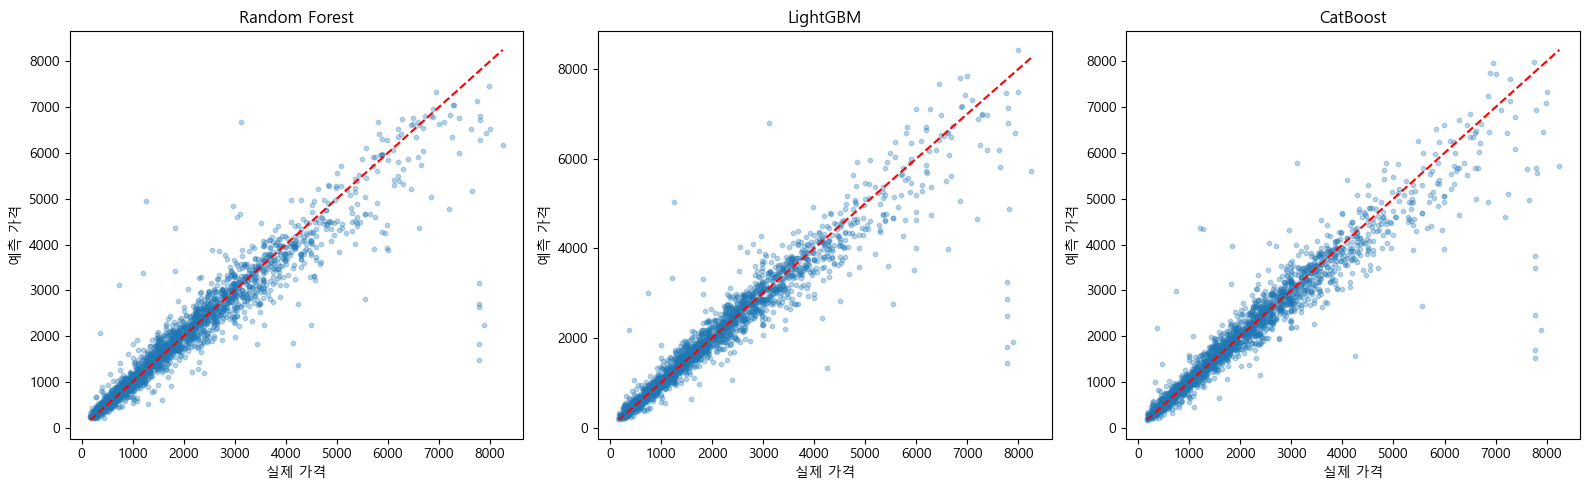

In [12]:
# 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = np.expm1(model.predict(X_test))
    y_true = np.expm1(y_test)

    ax.scatter(y_true, y_pred, alpha=0.3, s=10)
    ax.plot([y_true.min(), y_true.max()],
            [y_true.min(), y_true.max()], 'r--', lw=1.5)
    ax.set_title(name)
    ax.set_xlabel('실제 가격')
    ax.set_ylabel('예측 가격')

plt.tight_layout()
plt.show()


| 모델 | MAE | RMSE | R² | MAPE(%) | 순위 |
|---|---|---|---|---|---|
| **LightGBM** | **214.52** | 457.72 | **0.91** | **11.49** | MAE·MAPE 1위 |
| **CatBoost** | 216.32 | **449.96** | **0.91** | 11.66 | RMSE 1위 |
| Random Forest | 232.33 | 471.83 | 0.90 | 12.97 | 전 지표 3위 |

**해석:**
- **LightGBM**이 MAE·MAPE 기준 가장 우세 → 평균 오차가 가장 작음
- **CatBoost**는 RMSE 기준 가장 낮음 → 큰 오차 케이스를 잘 잡아냄
- **Random Forest**는 R² 0.90으로 소폭 낮고 전 지표 최하위
- LightGBM vs CatBoost 차이는 미미 → 실질적으로 **두 모델 성능 동등**

**결론:**
> 평균 오차 최소화가 목적이면 → **LightGBM**
> 극단적 고가/저가 예측 안정성이 목적이면 → **CatBoost**


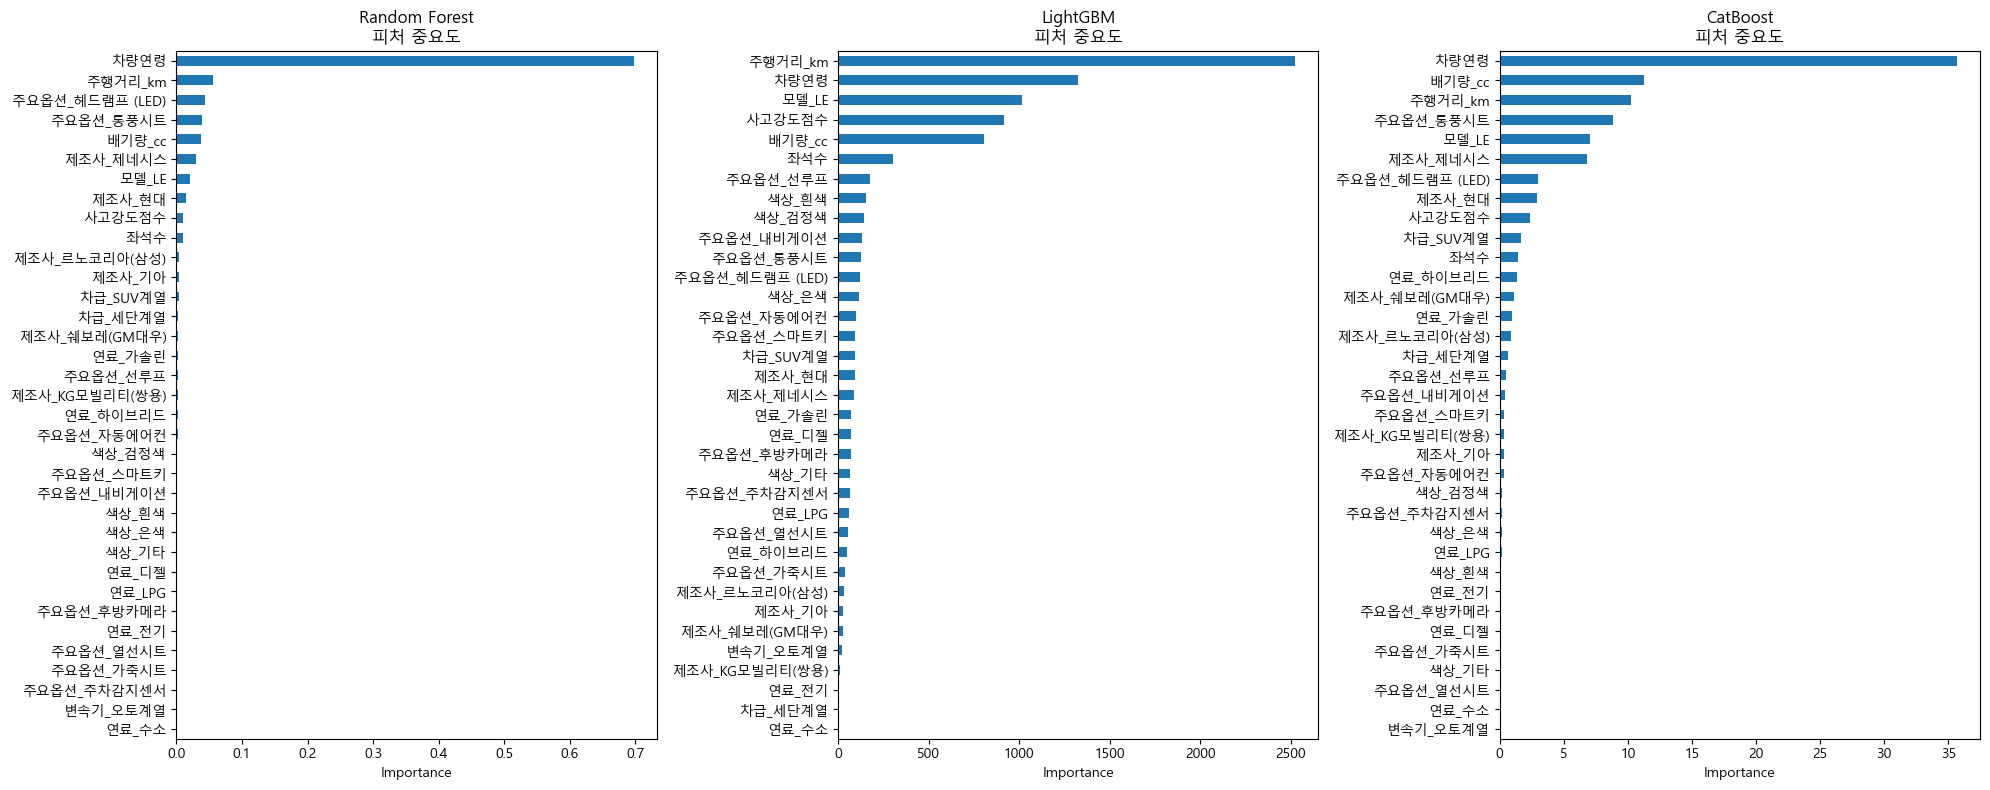

In [13]:
# 피처 중요도 추출
feat_names = X_train.columns.tolist()

importance_dict = {
    'Random Forest': rf_model.feature_importances_,
    'LightGBM'     : lgbm_model.feature_importances_,
    'CatBoost'     : cb_model.get_feature_importance(),
}

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, (name, importances) in zip(axes, importance_dict.items()):
    feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=True)

    feat_imp.plot(kind='barh', ax=ax)
    ax.set_title(f'{name}\n피처 중요도')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [14]:
# 수치로 확인
for name, importances in importance_dict.items():
    feat_imp = pd.Series(importances, index=feat_names)
    feat_imp = feat_imp / feat_imp.sum() * 100
    print(f"\n[{name}] 상위 10개")
    print(feat_imp.sort_values(ascending=False).head(10).round(2).to_string())


[Random Forest] 상위 10개
차량연령               69.74
주행거리_km             5.54
주요옵션_헤드램프 (LED)     4.33
주요옵션_통풍시트           3.95
배기량_cc              3.81
제조사_제네시스            2.93
모델_LE               2.01
제조사_현대              1.44
사고강도점수              1.03
좌석수                 1.03

[LightGBM] 상위 10개
주행거리_km       28.07
차량연령          14.71
모델_LE         11.29
사고강도점수        10.19
배기량_cc         8.93
좌석수            3.38
주요옵션_선루프       1.97
색상_흰색          1.69
색상_검정색         1.58
주요옵션_내비게이션     1.46

[CatBoost] 상위 10개
차량연령               35.69
배기량_cc             11.27
주행거리_km            10.23
주요옵션_통풍시트           8.81
모델_LE               7.03
제조사_제네시스            6.83
주요옵션_헤드램프 (LED)     3.01
제조사_현대              2.93
사고강도점수              2.34
차급_SUV계열            1.70


**공통적으로 중요한 피처 (3모델 모두 상위권)**

| 피처 | RF | LGBM | CatBoost | 해석 |
|---|---|---|---|---|
| 차량연령 | 69.74 | 14.71 | 35.69 | 연식이 오래될수록 가격 하락 → 가장 강력한 변수 |
| 주행거리_km | 5.54 | 28.07 | 10.23 | 주행거리 많을수록 감가 |
| 배기량_cc | 3.81 | 8.93 | 11.27 | 배기량 클수록 고가 차량 경향 |
| 모델_LE | 2.01 | 11.29 | 7.03 | 차종 자체가 가격 결정에 중요 |
| 사고강도점수 | 1.03 | 10.19 | 2.34 | 사고 이력이 가격에 영향 |

---

**모델별 특이점**

- **Random Forest** : 차량연령 69.74%로 **과도하게 편중** → 다른 피처를 제대로 활용 못하고 있어, 성능이 가장 낮은 이유와 연관됨

- **LightGBM** : 피처 중요도가 **가장 균형잡힘** → 다양한 피처를 고르게 학습, 성능 우수한 이유

- **CatBoost** : 차량연령 중심이지만 **옵션·제조사 변수도 반영** (통풍시트 8.81%, 제네시스 6.83%) → 브랜드 프리미엄을 잘 포착

---

**결론**
> 중고차 가격에 가장 큰 영향 = **차량연령 > 주행거리 > 배기량 > 차종**
> 사고 이력(사고강도점수)도 의미있는 변수로 확인됨


In [16]:
# !pip install optuna  # 설치 안 된 경우 주석 해제 후 실행
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)
print("optuna version:", optuna.__version__)

optuna version: 4.7.0


In [17]:
# ── Random Forest 튜닝 ───────────────────────────────────────
def rf_objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        'random_state'     : 42,
        'n_jobs'           : -1,
    }
    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return mean_squared_error(y_test, y_pred)

rf_study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
rf_study.optimize(rf_objective, n_trials=30, show_progress_bar=True)

print("RF 최적 파라미터:", rf_study.best_params)
print(f"RF 최적 MSE     : {rf_study.best_value:.6f}")

  0%|          | 0/30 [00:00<?, ?it/s]

RF 최적 파라미터: {'n_estimators': 143, 'max_depth': 21, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5}
RF 최적 MSE     : 0.034400


In [18]:
# ── LightGBM 튜닝 ────────────────────────────────────────────
def lgbm_objective(trial):
    params = {
        'n_estimators'  : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'     : trial.suggest_int('max_depth', 3, 12),
        'learning_rate' : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves'    : trial.suggest_int('num_leaves', 20, 150),
        'subsample'     : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'     : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'    : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state'  : 42,
        'n_jobs'        : -1,
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train, categorical_feature=cat_features_lgbm)
    y_pred = model.predict(X_test)
    return mean_squared_error(y_test, y_pred)

lgbm_study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
lgbm_study.optimize(lgbm_objective, n_trials=30, show_progress_bar=True)

print("LGBM 최적 파라미터:", lgbm_study.best_params)
print(f"LGBM 최적 MSE     : {lgbm_study.best_value:.6f}")


  0%|          | 0/30 [00:00<?, ?it/s]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000803 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 537
[LightGBM] [Info] Number of data points in the train set: 9063, number of used features: 35
[LightGBM] [Info] Start training from score 7.309478
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

In [19]:
# ── CatBoost 튜닝 ────────────────────────────────────────────
def cb_objective(trial):
    params = {
        'iterations'       : trial.suggest_int('iterations', 100, 500),
        'depth'            : trial.suggest_int('depth', 4, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg'      : trial.suggest_float('l2_leaf_reg', 1e-4, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength'  : trial.suggest_float('random_strength', 0.0, 1.0),
        'random_state'     : 42,
        'verbose'          : 0,
    }
    model = CatBoostRegressor(**params)
    model.fit(X_train, y_train, cat_features=cat_features_cb)
    y_pred = model.predict(X_test)
    return mean_squared_error(y_test, y_pred)

cb_study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
cb_study.optimize(cb_objective, n_trials=30, show_progress_bar=True)

print("CatBoost 최적 파라미터:", cb_study.best_params)
print(f"CatBoost 최적 MSE     : {cb_study.best_value:.6f}")


  0%|          | 0/30 [00:00<?, ?it/s]

CatBoost 최적 파라미터: {'iterations': 454, 'depth': 9, 'learning_rate': 0.051588661690455145, 'l2_leaf_reg': 0.0903896052731217, 'bagging_temperature': 0.11846857267631056, 'random_strength': 0.878627006583033}
CatBoost 최적 MSE     : 0.030282


In [20]:
# 최적 파라미터로 재학습
rf_tuned = RandomForestRegressor(
    n_estimators=143, max_depth=21, min_samples_split=5,
    min_samples_leaf=1, max_features=0.5, random_state=42, n_jobs=-1
)
rf_tuned.fit(X_train, y_train)

lgbm_tuned = lgb.LGBMRegressor(
    n_estimators=302, max_depth=8, learning_rate=0.0501,
    num_leaves=71, subsample=0.7626, colsample_bytree=0.7612,
    reg_alpha=0.0081, reg_lambda=1.6757, random_state=42, n_jobs=-1
)
lgbm_tuned.fit(X_train, y_train, categorical_feature=cat_features_lgbm)

cb_tuned = CatBoostRegressor(
    iterations=454, depth=9, learning_rate=0.0516,
    l2_leaf_reg=0.0904, bagging_temperature=0.1185,
    random_strength=0.8786, random_state=42, verbose=0
)
cb_tuned.fit(X_train, y_train, cat_features=cat_features_cb)

print("재학습 완료")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000632 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 537
[LightGBM] [Info] Number of data points in the train set: 9063, number of used features: 35
[LightGBM] [Info] Start training from score 7.309478
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

In [21]:
# 튜닝 전후 성능 비교
tuned_models = {
    'Random Forest': rf_tuned,
    'LightGBM'     : lgbm_tuned,
    'CatBoost'     : cb_tuned,
}

rows = []
for name, model in tuned_models.items():
    y_pred = np.expm1(model.predict(X_test))
    y_true = np.expm1(y_test)
    rows.append({
        '모델'    : name,
        'MAE'    : round(mean_absolute_error(y_true, y_pred), 2),
        'RMSE'   : round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        'R2'     : round(r2_score(y_true, y_pred), 2),
        'MAPE(%)': round(np.mean(np.abs((y_true - y_pred) / y_true)) * 100, 2),
    })

tuned_df = pd.DataFrame(rows).set_index('모델')
print("=== 튜닝 후 ===")
print(tuned_df)


=== 튜닝 후 ===
                  MAE    RMSE    R2  MAPE(%)
모델                                          
Random Forest  225.91  463.86  0.91    12.50
LightGBM       210.50  447.50  0.91    11.33
CatBoost       213.52  451.97  0.91    11.61


튜닝 전후 최종 비교:

| 모델 | MAE (전→후) | RMSE (전→후) | MAPE% (전→후) | 개선 |
|---|---|---|---|---|
| Random Forest | 232.33 → 225.91 | 471.83 → 463.86 | 12.97 → 12.50 | ↓소폭 개선 |
| **LightGBM** | 214.52 → **210.50** | 457.72 → **447.50** | 11.49 → **11.33** | ↓전 지표 개선 |
| CatBoost | 216.32 → 213.52 | 449.96 → 451.97 | 11.66 → 11.61 | △RMSE 소폭 악화 |

---

**최종 결론:**
- 튜닝 후에도 **LightGBM이 전 지표 1위**
- CatBoost RMSE가 튜닝 후 소폭 악화 → 튜닝 전 기본 파라미터가 오히려 나았음
- 3모델 모두 R² 0.91로 동일 → 전반적으로 안정적인 모델

> **최종 최적 모델 : LightGBM** (MAE 210.50, RMSE 447.50, MAPE 11.33%)

---

다음으로 진행할 수 있는 단계:
1. **최종 모델 저장** (`joblib`으로 pickle)
2. **실제 예측 테스트** - 임의 차량 정보 입력 → 가격 예측

In [24]:
# X_train 실제 컬럼 확인
print(X_train.columns.tolist())


['모델_LE', '주행거리_km', '배기량_cc', '좌석수', '차량연령', '사고강도점수', '주요옵션_선루프', '주요옵션_헤드램프 (LED)', '주요옵션_주차감지센서', '주요옵션_후방카메라', '주요옵션_자동에어컨', '주요옵션_스마트키', '주요옵션_내비게이션', '주요옵션_열선시트', '주요옵션_통풍시트', '주요옵션_가죽시트', '제조사_현대', '제조사_기아', '제조사_제네시스', '제조사_KG모빌리티(쌍용)', '제조사_쉐보레(GM대우)', '제조사_르노코리아(삼성)', '연료_LPG', '연료_가솔린', '연료_하이브리드', '연료_디젤', '연료_전기', '연료_수소', '색상_흰색', '색상_검정색', '색상_은색', '색상_기타', '변속기_오토계열', '차급_SUV계열', '차급_세단계열']


In [26]:
# ============================================================
# Step 9 : 실제 예측 테스트 (3개 샘플 차량)
# ============================================================
sample_cars = pd.DataFrame([
    {   # 차량 1: 현대 아반떼 (모델_LE=62), 5년, 6만km, 가솔린 1600cc
        '모델_LE': 62, '모델_평균가_TE': 1800.0,
        '주행거리_km': 60000, '배기량_cc': 1600, '좌석수': 5,
        '차량연령': 5, '사고강도점수': 0,
        '주요옵션_선루프': 0, '주요옵션_헤드램프 (LED)': 1, '주요옵션_주차감지센서': 1,
        '주요옵션_후방카메라': 1, '주요옵션_자동에어컨': 1, '주요옵션_스마트키': 1,
        '주요옵션_내비게이션': 1, '주요옵션_열선시트': 1, '주요옵션_통풍시트': 0,
        '주요옵션_가죽시트': 0,
        '제조사_현대': 1, '제조사_기아': 0, '제조사_제네시스': 0,
        '제조사_KG모빌리티(쌍용)': 0, '제조사_쉐보레(GM대우)': 0, '제조사_르노코리아(삼성)': 0,
        '연료_LPG': 0, '연료_가솔린': 1, '연료_하이브리드': 0, '연료_디젤': 0,
        '연료_전기': 0, '연료_수소': 0,
        '색상_흰색': 1, '색상_검정색': 0, '색상_은색': 0, '색상_기타': 0,
        '변속기_오토계열': 1, '차급_SUV계열': 0, '차급_세단계열': 1,
    },
    {   # 차량 2: 기아 K5 (모델_LE=11), 3년, 3만km, 하이브리드 2000cc
        '모델_LE': 11, '모델_평균가_TE': 2500.0,
        '주행거리_km': 30000, '배기량_cc': 2000, '좌석수': 5,
        '차량연령': 3, '사고강도점수': 0,
        '주요옵션_선루프': 1, '주요옵션_헤드램프 (LED)': 1, '주요옵션_주차감지센서': 1,
        '주요옵션_후방카메라': 1, '주요옵션_자동에어컨': 1, '주요옵션_스마트키': 1,
        '주요옵션_내비게이션': 1, '주요옵션_열선시트': 1, '주요옵션_통풍시트': 1,
        '주요옵션_가죽시트': 1,
        '제조사_현대': 0, '제조사_기아': 1, '제조사_제네시스': 0,
        '제조사_KG모빌리티(쌍용)': 0, '제조사_쉐보레(GM대우)': 0, '제조사_르노코리아(삼성)': 0,
        '연료_LPG': 0, '연료_가솔린': 0, '연료_하이브리드': 1, '연료_디젤': 0,
        '연료_전기': 0, '연료_수소': 0,
        '색상_흰색': 0, '색상_검정색': 1, '색상_은색': 0, '색상_기타': 0,
        '변속기_오토계열': 1, '차급_SUV계열': 0, '차급_세단계열': 1,
    },
    {   # 차량 3: 제네시스 GV80 (모델_LE=9), 2년, 2만km, 디젤 3000cc
        '모델_LE': 9, '모델_평균가_TE': 6500.0,
        '주행거리_km': 20000, '배기량_cc': 3000, '좌석수': 5,
        '차량연령': 2, '사고강도점수': 0,
        '주요옵션_선루프': 1, '주요옵션_헤드램프 (LED)': 1, '주요옵션_주차감지센서': 1,
        '주요옵션_후방카메라': 1, '주요옵션_자동에어컨': 1, '주요옵션_스마트키': 1,
        '주요옵션_내비게이션': 1, '주요옵션_열선시트': 1, '주요옵션_통풍시트': 1,
        '주요옵션_가죽시트': 1,
        '제조사_현대': 0, '제조사_기아': 0, '제조사_제네시스': 1,
        '제조사_KG모빌리티(쌍용)': 0, '제조사_쉐보레(GM대우)': 0, '제조사_르노코리아(삼성)': 0,
        '연료_LPG': 0, '연료_가솔린': 0, '연료_하이브리드': 0, '연료_디젤': 1,
        '연료_전기': 0, '연료_수소': 0,
        '색상_흰색': 0, '색상_검정색': 0, '색상_은색': 1, '색상_기타': 0,
        '변속기_오토계열': 1, '차급_SUV계열': 1, '차급_세단계열': 0,
    },
])[X_train.columns]   # 학습 컬럼 순서에 맞춤

# ── 예측 ──────────────────────────────────────────────────────
pred_log = lgbm_tuned.predict(sample_cars)
pred_price = np.expm1(pred_log)

# ── 결과 출력 ─────────────────────────────────────────────────
car_labels = ['현대 아반떼 (5년/6만km/가솔린)', '기아 K5 (3년/3만km/하이브리드)', '제네시스 GV80 (2년/2만km/디젤)']
print("=" * 55)
print("          실제 예측 결과 (LightGBM Tuned)")
print("=" * 55)
for label, price in zip(car_labels, pred_price):
    print(f"  {label:<30} → {price:,.0f} 만원")
print("=" * 55)


          실제 예측 결과 (LightGBM Tuned)
  현대 아반떼 (5년/6만km/가솔린)           → 1,910 만원
  기아 K5 (3년/3만km/하이브리드)          → 3,278 만원
  제네시스 GV80 (2년/2만km/디젤)         → 7,110 만원
